# Přednáška 1: Vícerozměrná náhodná veličina — praktický doprovod

Doplňkový notebook k `P01b_nahodny_vektor.tex` (KMA/MSM). Pojmy z přednášky
(sdružené rozdělení, marginály, nezávislost, střední hodnota, varianční
a kovarianční matice, korelace, podmíněné rozdělení) ověřujeme jednak
**symbolicky** (SymPy — na hustotě z přednáškového příkladu), jednak
**numericky/simulačně** (NumPy — na vzorku dat).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy import stats

np.random.seed(42)
plt.rcParams["figure.figsize"] = (5, 4)


## 1. Vícerozměrná náhodná veličina

Náhodný vektor $\boldsymbol X = (X_1, \ldots, X_k)$. Pro ukázku vygenerujeme
třírozměrný náhodný vektor (např. $k=3$) ze sdruženého normálního rozdělení —
budeme ho používat jako pracovní příklad v částech o střední hodnotě,
rozptylu a kovarianci.

In [2]:
k = 3
mu_true = np.array([1.0, 0.0, -2.0])
Sigma_true = np.array([
    [2.0, 0.8, -0.3],
    [0.8, 1.5,  0.4],
    [-0.3, 0.4, 1.0]
])

n = 5000
X = np.random.multivariate_normal(mu_true, Sigma_true, size=n)
print("Rozměr vzorku:", X.shape)
X[:5]


Rozměr vzorku: (5000, 3)


array([[ 0.48051776, -0.64047609, -1.57950276],
       [-1.15703838, -1.20143757, -1.88991537],
       [-0.81864067, -1.82107615, -2.88857045],
       [-0.06365772, -0.02465864, -1.79638393],
       [-0.74131477,  1.72053886, -1.07994757]])

## 2. Sdružené distribuční funkce a sdružené funkce hustoty

Vizualizace sdružené hustoty pro první dvě složky $\left(X_1, X_2\right)$
— odhad hustoty z dat (2D histogram) vs. teoretická kontura sdruženého
normálního rozdělení.

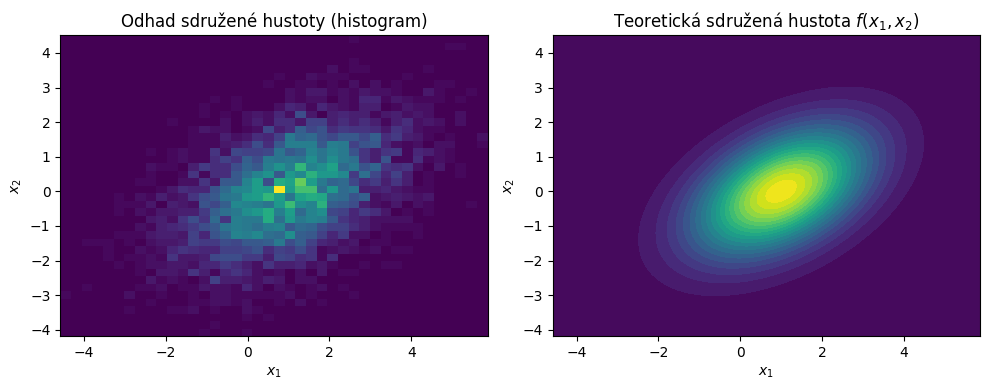

In [3]:
from scipy.stats import multivariate_normal

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist2d(X[:, 0], X[:, 1], bins=40, cmap="viridis")
axes[0].set_title("Odhad sdružené hustoty (histogram)")
axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$x_2$")

xx, yy = np.meshgrid(np.linspace(X[:,0].min(), X[:,0].max(), 100),
                      np.linspace(X[:,1].min(), X[:,1].max(), 100))
pos = np.dstack((xx, yy))
rv = multivariate_normal(mu_true[:2], Sigma_true[:2, :2])
axes[1].contourf(xx, yy, rv.pdf(pos), levels=20, cmap="viridis")
axes[1].set_title("Teoretická sdružená hustota $f(x_1,x_2)$")
axes[1].set_xlabel("$x_1$"); axes[1].set_ylabel("$x_2$")

plt.tight_layout()
plt.show()


## 3. Diskrétní a spojitý vektor

**Diskrétní příklad** — pravděpodobnostní funkce $P(x_1,x_2)$ zadaná tabulkou
(house-keeping příklad: hod dvěma kostkami, $X_1$ = součet, $X_2$ = max
z obou kostek).

In [4]:
faces = np.arange(1, 7)
rolls = np.array([(a, b) for a in faces for b in faces])
X1 = rolls.sum(axis=1)     # součet
X2 = rolls.max(axis=1)     # maximum

import pandas as pd
joint_counts = pd.crosstab(X1, X2)
joint_pmf = joint_counts / joint_counts.values.sum()
joint_pmf.round(3)


col_0,1,2,3,4,5,6
row_0,,,,,,
2,0.028,0.000,0.000,0.000,0.000,0.000
3,0.000,0.056,0.000,0.000,0.000,0.000
4,0.000,0.028,0.056,0.000,0.000,0.000
5,0.000,0.000,0.056,0.056,0.000,0.000
6,0.000,0.000,0.028,0.056,0.056,0.000
7,0.000,0.000,0.000,0.056,0.056,0.056
8,0.000,0.000,0.000,0.028,0.056,0.056
9,0.000,0.000,0.000,0.000,0.056,0.056
10,0.000,0.000,0.000,0.000,0.028,0.056


**Spojitý příklad** — hustota $f(x,y) = c\left(\frac{x}{2}+\frac{y}{3}\right)$
na $x\in(0,2),\ y\in(0,3)$ — stejný příklad, který na konci přednášky
počítáme ručně. Tady ho jen deklarujeme symbolicky, plný výpočet je
v sekci 8.

In [5]:
x, y, c = sp.symbols('x y c', positive=True)
f_xy = c * (x/2 + y/3)
f_xy


c*(x/2 + y/3)

## 4. Marginální rozdělení

Marginální hustotu/pravděpodobnostní funkci získáme "vysčítáním"/integrací
přes ostatní složky. U diskrétního příkladu (kostky) porovnáme marginál
$P(X_1)$ získaný ze sdružené tabulky se stejným výpočtem přímo z dat.

In [6]:
marginal_X1 = joint_pmf.sum(axis=1)
marginal_X2 = joint_pmf.sum(axis=0)

print("Marginální rozdělení X1 (součet ok):", np.isclose(marginal_X1.sum(), 1))
marginal_X1


Marginální rozdělení X1 (součet ok): True


row_0
2     0.027778
3     0.055556
4     0.083333
5     0.111111
6     0.138889
7     0.166667
8     0.138889
9     0.111111
10    0.083333
11    0.055556
12    0.027778
dtype: float64

U spojitého vzorku (viz sekce 1) odhadneme marginální hustotu $X_1$ histogramem:

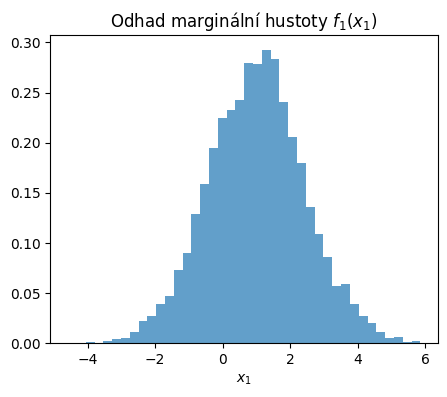

In [7]:
plt.hist(X[:, 0], bins=40, density=True, alpha=0.7)
plt.title("Odhad marginální hustoty $f_1(x_1)$")
plt.xlabel("$x_1$")
plt.show()


## 5. Nezávislost náhodných veličin

$X_1, \ldots, X_k$ jsou nezávislé, pokud $f(x_1,\ldots,x_k) = f_1(x_1)\cdots f_k(x_k)$.
Vygenerujeme dva páry: jeden nezávislý, jeden závislý, a porovnáme rozptyly bodů
(vizuálně) i korelaci (číselně).

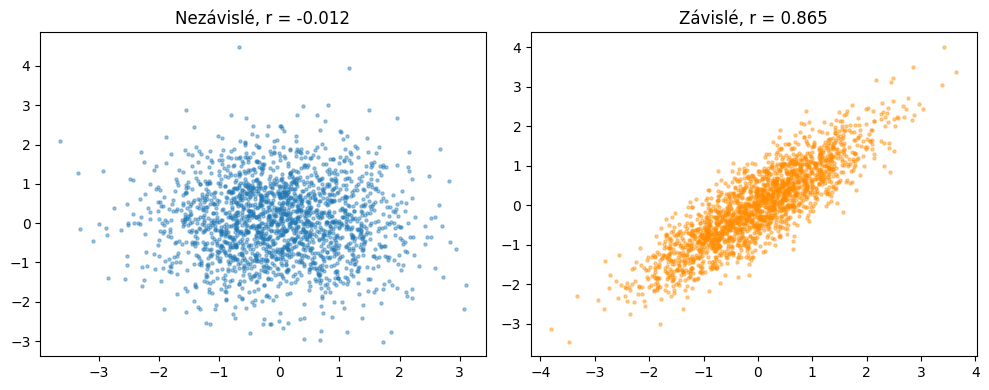

In [8]:
n2 = 2000
independent = np.random.multivariate_normal([0, 0], [[1, 0], [0, 1]], n2)
dependent   = np.random.multivariate_normal([0, 0], [[1, 0.85], [0.85, 1]], n2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(independent[:, 0], independent[:, 1], s=5, alpha=0.4)
axes[0].set_title(f"Nezávislé, r = {np.corrcoef(independent.T)[0,1]:.3f}")
axes[1].scatter(dependent[:, 0], dependent[:, 1], s=5, alpha=0.4, color="darkorange")
axes[1].set_title(f"Závislé, r = {np.corrcoef(dependent.T)[0,1]:.3f}")
plt.tight_layout()
plt.show()


## 6. Podmíněné rozdělení

Podmíněná hustota $f(x\,|\,y) = f(x,y)/f_y(y)$. Ukázka na sdruženém
normálním rozdělení $(X_1,X_2)$ ze sekce 1 — podmíněné rozdělení
$X_1\,|\,X_2=y_0$ je opět normální (vlastnost vícerozměrného normálního
rozdělení) se vzorcem
$$\mathbb{E}(X_1\mid X_2=y_0) = \mu_1 + \frac{\sigma_{12}}{\sigma_{22}}(y_0-\mu_2), \qquad
\mathrm{var}(X_1\mid X_2=y_0) = \sigma_{11} - \frac{\sigma_{12}^2}{\sigma_{22}}.$$

In [9]:
y0 = 1.0
mu1, mu2 = mu_true[0], mu_true[1]
s11, s12, s22 = Sigma_true[0,0], Sigma_true[0,1], Sigma_true[1,1]

cond_mean = mu1 + s12/s22 * (y0 - mu2)
cond_var  = s11 - s12**2/s22

print(f"E(X1 | X2={y0}) = {cond_mean:.4f}")
print(f"var(X1 | X2={y0}) = {cond_var:.4f}")

# ověření simulací: vezmeme jen body blízko X2 ≈ y0 a spočteme jejich statistiky
mask = np.abs(X[:, 1] - y0) < 0.1
print(f"\nSimulačně (n={mask.sum()} bodů blízko X2={y0}):")
print(f"  odhad E(X1|X2≈{y0}) = {X[mask, 0].mean():.4f}")
print(f"  odhad var(X1|X2≈{y0}) = {X[mask, 0].var(ddof=1):.4f}")


E(X1 | X2=1.0) = 1.5333
var(X1 | X2=1.0) = 1.5733

Simulačně (n=234 bodů blízko X2=1.0):
  odhad E(X1|X2≈1.0) = 1.5584
  odhad var(X1|X2≈1.0) = 1.6302


## 7. Střední hodnota a rozptyl vektoru

$\mathbb{E}\boldsymbol X = (\mathbb{E} X_1,\ldots,\mathbb{E} X_k)$, $\mathrm{var} \boldsymbol X = (\mathrm{var} X_1,\ldots,\mathrm{var} X_k)$.
Odhad ze vzorku vs. teoretické (`mu_true`).

In [10]:
EX_hat = X.mean(axis=0)
varX_hat = X.var(axis=0, ddof=1)

print("Odhad E(X):        ", EX_hat.round(3))
print("Teoretické mu:      ", mu_true)
print()
print("Odhad var(X):       ", varX_hat.round(3))
print("Teoretická diag(Σ): ", np.diag(Sigma_true))


Odhad E(X):         [ 1.004 -0.003 -2.004]
Teoretické mu:       [ 1.  0. -2.]

Odhad var(X):        [2.04  1.474 1.013]
Teoretická diag(Σ):  [2.  1.5 1. ]


## 8. Kovarianční a varianční matice

Varianční matice $\mathrm{Var}\boldsymbol X = \mathbb{E}\left[(\boldsymbol X-\mathbb{E}\boldsymbol X)(\boldsymbol X-\mathbb{E}\boldsymbol X)^T\right]$.
Spočteme ji ze vzorku (`np.cov`) a porovnáme s teoretickou $\Sigma$.

In [11]:
Sigma_hat = np.cov(X, rowvar=False)

print("Odhad varianční matice:\n", Sigma_hat.round(3))
print("\nTeoretická varianční matice:\n", Sigma_true)


Odhad varianční matice:
 [[ 2.04   0.788 -0.293]
 [ 0.788  1.474  0.422]
 [-0.293  0.422  1.013]]

Teoretická varianční matice:
 [[ 2.   0.8 -0.3]
 [ 0.8  1.5  0.4]
 [-0.3  0.4  1. ]]


**Ověření vlastností varianční matice** (symetrie, pozitivní semidefinitnost, vzorec $\mathrm{Var}\boldsymbol X=\mathbb{E}(\boldsymbol X\boldsymbol X^T)-\mathbb{E}\boldsymbol X\,\mathbb{E}\boldsymbol X^T$):

In [12]:
# i) symetrie
print("Symetrická?", np.allclose(Sigma_hat, Sigma_hat.T))

# ii) pozitivní semidefinitnost: c^T Sigma c >= 0 pro libovolné c
c_vec = np.random.randn(k)
print("c^T Var(X) c >= 0 ?", (c_vec @ Sigma_hat @ c_vec) >= 0)

# iii) Var(X) = E(XX^T) - E(X)E(X)^T
EXXt = (X.T @ X) / n
EX_outer = np.outer(EX_hat, EX_hat)
print("Shoda se vzorcem E(XX^T) - E(X)E(X)^T:",
      np.allclose(Sigma_hat, EXXt - EX_outer, atol=0.05))


Symetrická? True
c^T Var(X) c >= 0 ? True
Shoda se vzorcem E(XX^T) - E(X)E(X)^T: True


## 9. Korelační matice

$\mathrm{cor}(X_i,X_j) = \dfrac{\mathrm{cov}(X_i,X_j)}{\sqrt{\mathrm{var}(X_i)\mathrm{var}(X_j)}}$

In [13]:
corr_hat = np.corrcoef(X, rowvar=False)
print("Odhad korelační matice:\n", corr_hat.round(3))

# ověření vlastností: diagonála = 1, hodnoty v (-1, 1), symetrie
print("\nDiagonála ≈ 1?", np.allclose(np.diag(corr_hat), 1))
print("Symetrická?      ", np.allclose(corr_hat, corr_hat.T))
print("Všechny v (-1,1)?", np.all(np.abs(corr_hat - np.eye(k)) < 1))


Odhad korelační matice:
 [[ 1.     0.455 -0.204]
 [ 0.455  1.     0.345]
 [-0.204  0.345  1.   ]]

Diagonála ≈ 1? True
Symetrická?       True
Všechny v (-1,1)? True


## 10. Nezávislé veličiny — součet středních hodnot a rozptylů

Pro nezávislé $X_1,\ldots,X_k$: $\mathrm{var}(\sum X_i) = \sum \mathrm{var}(X_i)$
(kovariance vypadnou). Ověříme na vzorku nezávislých normálních veličin.

In [14]:
indep_vars = np.array([2.0, 0.5, 1.3])
n3 = 20000
Xi = np.random.randn(n3, 3) * np.sqrt(indep_vars)

var_soucet_teor = indep_vars.sum()
var_soucet_odhad = Xi.sum(axis=1).var(ddof=1)

print(f"Teoretický var(sum Xi) = {var_soucet_teor:.4f}")
print(f"Odhad var(sum Xi)      = {var_soucet_odhad:.4f}")


Teoretický var(sum Xi) = 3.8000
Odhad var(sum Xi)      = 3.8196


## 11. Podmíněná střední hodnota a rozptyl — zákon celkové pravděpodobnosti

$$\mathbb{E}(Y) = \mathbb{E}\left(\mathbb{E}(Y\mid X)\right), \qquad
\mathrm{var}(Y) = \mathbb{E}\left(\mathrm{var}(Y\mid X)\right) + \mathrm{var}\left(\mathbb{E}(Y\mid X)\right)$$

Ověříme na vzorku $(X_1, X_2)$ ze sekce 1, kde $Y = X_1$, $X = X_2$.

In [15]:
Y = X[:, 0]
Xc = X[:, 1]

# rozdělíme X do binů a spočteme podmíněný průměr/rozptyl v každém binu
bins = np.linspace(Xc.min(), Xc.max(), 25)
bin_idx = np.digitize(Xc, bins)

cond_means, cond_vars, weights = [], [], []
for b in np.unique(bin_idx):
    mask = bin_idx == b
    if mask.sum() > 5:
        cond_means.append(Y[mask].mean())
        cond_vars.append(Y[mask].var(ddof=1))
        weights.append(mask.sum())

cond_means = np.array(cond_means); cond_vars = np.array(cond_vars)
weights = np.array(weights) / np.sum(weights)

E_of_condmean = np.sum(weights * cond_means)
E_of_condvar  = np.sum(weights * cond_vars)
var_of_condmean = np.sum(weights * (cond_means - E_of_condmean)**2)

print(f"E(Y) přímo               = {Y.mean():.4f}")
print(f"E(E(Y|X)) (dle binů)     = {E_of_condmean:.4f}")
print()
print(f"var(Y) přímo             = {Y.var(ddof=1):.4f}")
print(f"E(var(Y|X)) + var(E(Y|X)) = {E_of_condvar + var_of_condmean:.4f}")


E(Y) přímo               = 1.0042
E(E(Y|X)) (dle binů)     = 1.0028

var(Y) přímo             = 2.0396
E(var(Y|X)) + var(E(Y|X)) = 2.0396


## 12. Řešený příklad z přednášky (symbolicky přes SymPy)

$$f(x,y) = c\left(\frac{x}{2}+\frac{y}{3}\right), \qquad x\in(0,2),\ y\in(0,3)$$

V přednášce vyšlo: $\mathbb{E} X=\frac{7}{6}$, $\mathbb{E} Y=\frac{7}{4}$, $\mathrm{var} X=\frac{11}{36}$,
$\mathrm{var} Y=\frac{11}{16}$, $\mathrm{cov}(X,Y) = -\frac{1}{24}$ (tedy $X,Y$ jsou závislé).
Ověříme to tady krok za krokem symbolicky.

In [16]:
x, y, c = sp.symbols('x y c', real=True)
f_raw = x/2 + y/3

# 1) normalizační konstanta c: dvojný integrál musí dát 1
integral_raw = sp.integrate(sp.integrate(f_raw, (x, 0, 2)), (y, 0, 3))
c_val = sp.solve(sp.Eq(c * integral_raw, 1), c)[0]
print("Normalizační konstanta c =", c_val)

f_xy = c_val * f_raw
f_xy


Normalizační konstanta c = 1/6


x/12 + y/18

In [17]:
# marginální hustoty
f_x = sp.integrate(f_xy, (y, 0, 3))
f_y = sp.integrate(f_xy, (x, 0, 2))
print("f_X(x) =", sp.simplify(f_x))
print("f_Y(y) =", sp.simplify(f_y))


f_X(x) = x/4 + 1/4
f_Y(y) = y/9 + 1/6


In [18]:
EX = sp.integrate(x * f_x, (x, 0, 2))
EY = sp.integrate(y * f_y, (y, 0, 3))
print("E(X) =", EX, " (přednáška: 7/6 =", sp.Rational(7,6), ")")
print("E(Y) =", EY, " (přednáška: 7/4 =", sp.Rational(7,4), ")")


E(X) =

 7/6  (přednáška: 7/6 = 7/6 )
E(Y) = 7/4  (přednáška: 7/4 = 7/4 )


In [19]:
EX2 = sp.integrate(x**2 * f_x, (x, 0, 2))
EY2 = sp.integrate(y**2 * f_y, (y, 0, 3))
varX = sp.simplify(EX2 - EX**2)
varY = sp.simplify(EY2 - EY**2)
print("var(X) =", varX, " (přednáška: 11/36 =", sp.Rational(11,36), ")")
print("var(Y) =", varY, " (přednáška: 11/16 =", sp.Rational(11,16), ")")


var(X) =

 11/36  (přednáška: 11/36 = 11/36 )
var(Y) = 11/16  (přednáška: 11/16 = 11/16 )


In [20]:
EXY = sp.integrate(sp.integrate(x*y * f_xy, (x, 0, 2)), (y, 0, 3))
covXY = sp.simplify(EXY - EX*EY)
print("cov(X,Y) =", covXY, " (přednáška: -1/24 =", sp.Rational(-1,24), ")")

print("\nX a Y jsou tedy", "nezávislé" if covXY == 0 else "závislé (cov != 0)")


cov(X,Y) =

 -1/24  (přednáška: -1/24 = -1/24 )

X a Y jsou tedy závislé (cov != 0)


### Shrnutí porovnání s přednáškou

| Veličina | Přednáška | SymPy |
|---|---|---|
| $c$ | (dopočítat z normalizace) | viz výše |
| $\mathbb{E} X$ | $7/6$ | viz výše |
| $\mathbb{E} Y$ | $7/4$ | viz výše |
| $\mathrm{var} X$ | $11/36$ | viz výše |
| $\mathrm{var} Y$ | $11/16$ | viz výše |
| $\mathrm{cov}(X,Y)$ | $-1/24$ | viz výše |

Pokud se `sympy` výstupy neshodují s hodnotami z přednášky, zkontroluj hranice
integrálů/zadání příkladu — nejčastější zdroj rozdílu bývá přehozené pořadí
integrace nebo špatně dosazené meze.
